In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Using the absolute path so Jupyter knows EXACTLY where to look
file_path = "/Users/mennatarek/Desktop/product-performance-intelligence/Sample - Superstore.csv"

df = pd.read_csv(file_path, encoding='latin1')
print("✅ SUCCESS: Dataset loaded perfectly!")

✅ SUCCESS: Dataset loaded perfectly!


In [6]:
df.shape

(9994, 21)

In [7]:
import numpy as np

# ================================
# 1. DATA CLEANING
# ================================

# Convert the text dates into actual Datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Print out a check to see if we have any missing (null) values
print("Missing values in each column:")
print(df.isnull().sum())

# Drop any rows that have missing data to keep our analysis clean
df = df.dropna()

# ================================
# 2. FEATURE ENGINEERING
# ================================

# Create a new 'Profit Margin' column (Profit divided by Sales).
# We use np.where to make sure we don't accidentally divide by zero if a sale was $0!
df['Profit Margin'] = np.where(df['Sales'] != 0, df['Profit'] / df['Sales'], 0)

# Preview the updated dataset to make sure our new column is there
print("\nDataset successfully cleaned! Here is a preview with the new Profit Margin:")
display(df.head())


Missing values in each column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Dataset successfully cleaned! Here is a preview with the new Profit Margin:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.1600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.3000
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.4700
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-0.4000
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.1125


In [8]:
# ================================
# 3. EXECUTIVE BUSINESS ANALYSIS
# ================================
import pandas as pd
import numpy as np

# A) PRODUCT ANALYSIS
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False)
print("🏆 Top 5 Most Profitable Products:")
display(product_profit.head(5).to_frame())

print("\n🚨 Top 5 Biggest Money-Losing Products:")
display(product_profit.tail(5).to_frame())

# B) REGIONAL ANALYSIS
regional_analysis = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)
print("\n🌍 Regional Performance (Sales vs. Profit):")
display(regional_analysis)

# C) DISCOUNT STRATEGY
discount_analysis = df.groupby('Discount')['Profit Margin'].mean().reset_index()
print("\n💸 Average Profit Margin by Discount Level:")
display(discount_analysis.head(10))

# ================================
# 4. EXPORT FOR POWER BI (BULLETPROOF VERSION)
# ================================
import os

# Let's see where Jupyter was secretly hiding your files
print("Jupyter was secretly saving files here:", os.getcwd())

# Force Python to save it EXACTLY to your project folder on your Desktop
exact_path = "/Users/mennatarek/Desktop/product-performance-intelligence/cleaned_superstore.csv"

df.to_csv(exact_path, index=False)

print("\n✅ SUCCESS: Dataset forced to save exactly at:", exact_path)

🏆 Top 5 Most Profitable Products:


,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
Hewlett Packard LaserJet 3310 Copier,6983.8836
Canon PC1060 Personal Laser Copier,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766



🚨 Top 5 Biggest Money-Losing Products:


,Profit
Product Name,
Bush Advantage Collection Racetrack Conference Table,-1934.3976
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-2876.1156
Cubify CubeX 3D Printer Triple Head Print,-3839.9904
Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
Cubify CubeX 3D Printer Double Head Print,-8879.9704



🌍 Regional Performance (Sales vs. Profit):


,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
South,391721.9050,46749.4303
Central,501239.8908,39706.3625



💸 Average Profit Margin by Discount Level:


,Discount,Profit Margin
0,0.00,0.340160
1,0.10,0.155792
2,0.15,0.034163
3,0.20,0.176839
4,0.30,-0.115481
5,0.32,-0.174292
6,0.40,-0.222492
7,0.45,-0.454545
8,0.50,-0.549091
9,0.60,-0.689130


Jupyter was secretly saving files here: /Users/mennatarek/Desktop

✅ SUCCESS: Dataset forced to save exactly at: /Users/mennatarek/Desktop/product-performance-intelligence/cleaned_superstore.csv


In [9]:
%pip install seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Generating business visualizations...



/var/folders/t0/fmx45w2n48bg0r70vjf4qy7c0000gq/T/ipykernel_9232/1148776630.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subcat_profit.values, y=subcat_profit.index, palette="viridis")


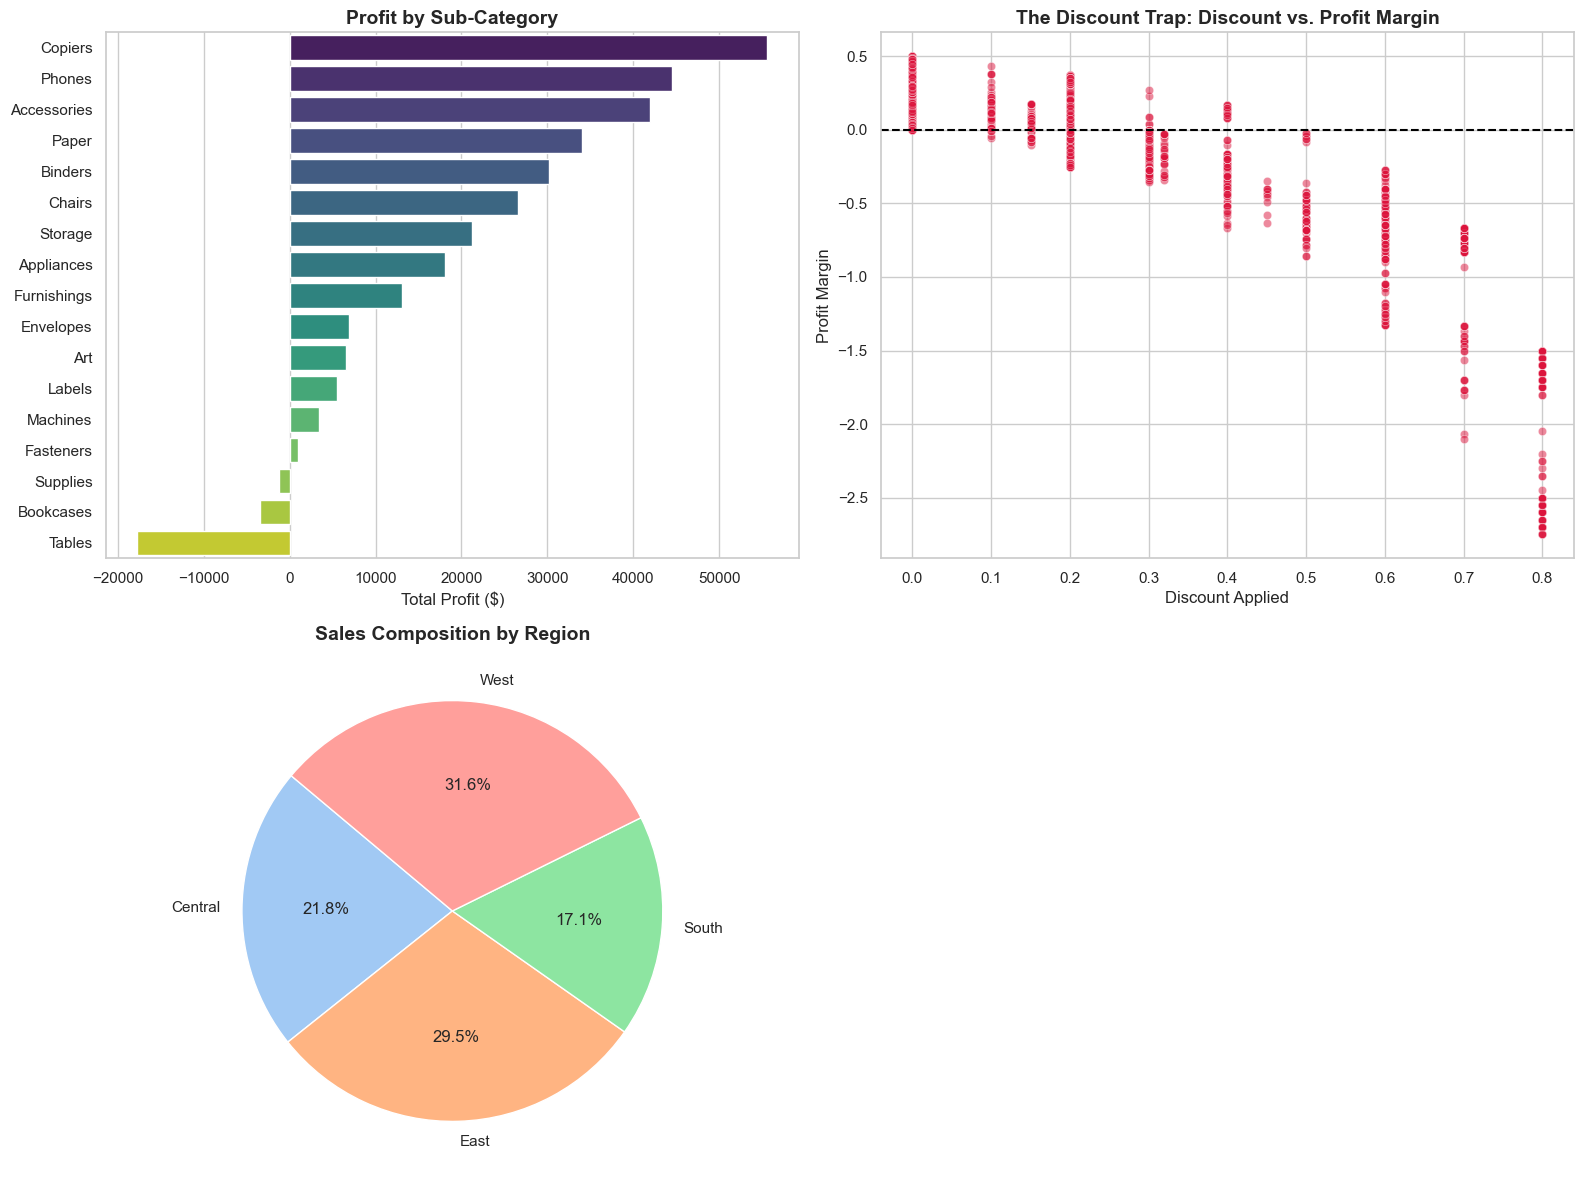

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for our charts to look professional
sns.set_theme(style="whitegrid")

# ================================
# 5. BUSINESS VISUALIZATIONS
# ================================
print("Generating business visualizations...\n")

plt.figure(figsize=(16, 12))

# -- CHART 1: COMPARISON (Bar Chart) --
# Question: Which sub-categories are actually driving profit?
plt.subplot(2, 2, 1)
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=subcat_profit.values, y=subcat_profit.index, palette="viridis")
plt.title("Profit by Sub-Category", fontsize=14, fontweight='bold')
plt.xlabel("Total Profit ($)")
plt.ylabel("")

# -- CHART 2: RELATIONSHIP (Scatter Plot) --
# Question: Does giving a higher discount increase or destroy profit?
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='Discount', y='Profit Margin', alpha=0.5, color='crimson')
plt.axhline(0, color='black', linestyle='--') # Add a line at $0 profit
plt.title("The Discount Trap: Discount vs. Profit Margin", fontsize=14, fontweight='bold')
plt.xlabel("Discount Applied")
plt.ylabel("Profit Margin")

# -- CHART 3: COMPOSITION (Pie Chart) --
# Question: What is our market share breakdown by Region?
plt.subplot(2, 2, 3)
region_sales = df.groupby('Region')['Sales'].sum()
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Sales Composition by Region", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Generating advanced marketing insights...



/var/folders/t0/fmx45w2n48bg0r70vjf4qy7c0000gq/T/ipykernel_9232/2313182330.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_profit.index, y=segment_profit.values, palette="magma")


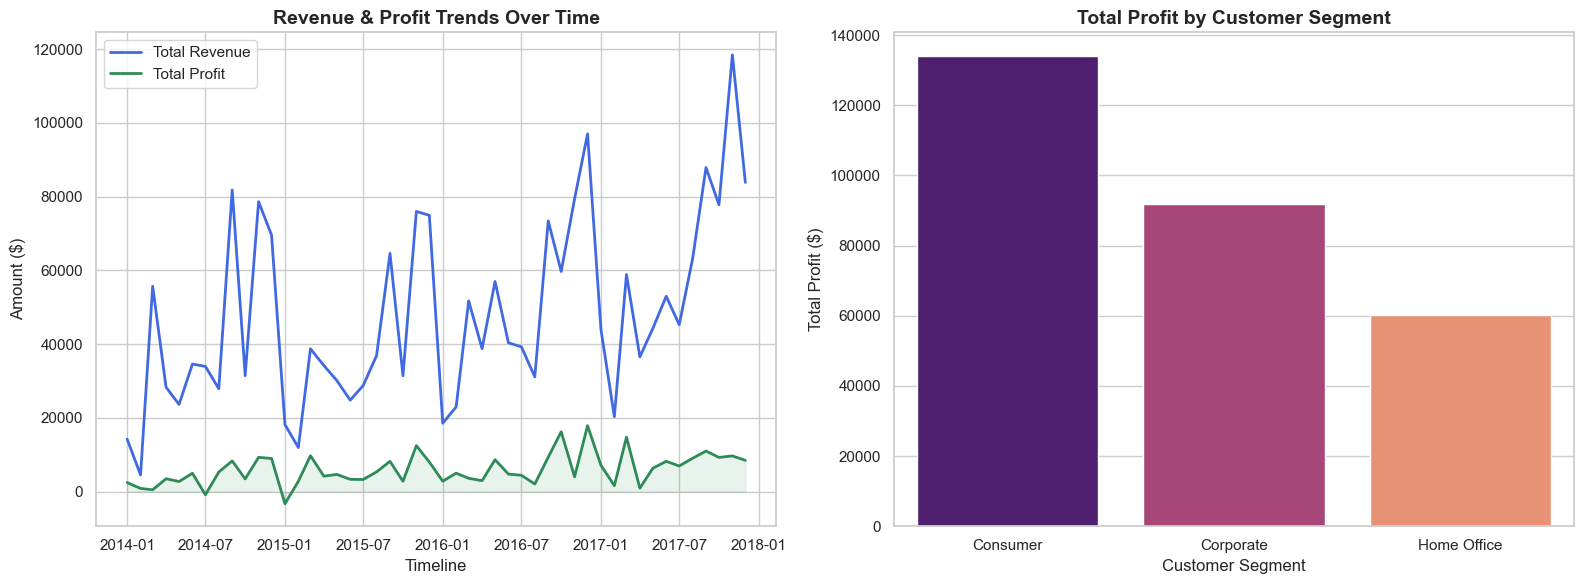

In [12]:
# ================================
# 6. ADVANCED MARKETING VISUALIZATIONS
# ================================
print("Generating advanced marketing insights...\n")

# Had to make sure the date is recognized as a 'datetime' object to plot it on a timeline
df['Order Date'] = pd.to_datetime(df['Order Date'])

plt.figure(figsize=(16, 6))

# -- CHART 4: TIME SERIES - line chart
# Question: When do we make the most money? (Seasonality)
plt.subplot(1, 2, 1)

# Group the data by Year and Month
monthly_trend = df.groupby(df['Order Date'].dt.to_period('M'))[['Sales', 'Profit']].sum().reset_index()
monthly_trend['Order Date'] = monthly_trend['Order Date'].dt.to_timestamp()

sns.lineplot(data=monthly_trend, x='Order Date', y='Sales', label='Total Revenue', color='royalblue', linewidth=2)
sns.lineplot(data=monthly_trend, x='Order Date', y='Profit', label='Total Profit', color='seagreen', linewidth=2)
plt.fill_between(monthly_trend['Order Date'], monthly_trend['Profit'], color='seagreen', alpha=0.1) # Highlights the profit area

plt.title("Revenue & Profit Trends Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Timeline")
plt.ylabel("Amount ($)")

# -- CHART 5: CUSTOMER SEGMENTATION - bar chart
# Question: Who is our most valuable customer base?
plt.subplot(1, 2, 2)
segment_profit = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=segment_profit.index, y=segment_profit.values, palette="magma")

plt.title("Total Profit by Customer Segment", fontsize=14, fontweight='bold')
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit ($)")

plt.tight_layout()
plt.show()